In [1]:
import pandas as pd 
import numpy as np 

Rows, Columns: (10000, 18)

Column names: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned']

Data types:
 RowNumber               int64
CustomerId              int64
Surname                object
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object

First 5 rows:
    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    Fran


Total missing values in dataset: 0

Fully duplicated rows: 0

Sanity check results (count of invalid rows found):
  CreditScore (300-850 valid FICO range): 0
  Age <18 or >100: 0
  Negative Balance: 0
  Negative EstimatedSalary: 0
  NumOfProducts <= 0: 0
  Satisfaction Score outside 1-5: 0
  Complain not in {0,1}: 0
  Exited not in {0,1}: 0
  HasCrCard not in {0,1}: 0
  IsActiveMember not in {0,1}: 0

Gender value counts:
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Geography value counts:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Card Type value counts:
Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64

HasCrCard value counts:
HasCrCard
1    7055
0    2945
Name: count, dtype: int64

IsActiveMember value counts:
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64



===== CLEANING SUMMARY =====
Shape before cleaning: (10000, 18)
Shape after cleaning : (10000, 16)
Columns removed: ['RowNumber', 'Surname']
  - RowNumber: Pure row index (1..10000). Carries no information about the customer and would only leak row-order as a fake pattern to the model.
  - Surname: Customer last name is a free-text identifier with no genuine predictive relationship to churn behavior.
CustomerId note: Unique numeric identifier (10000 unique values across 10000 rows). Not dropped at cleaning stage so records stay traceable, but must be excluded from ML input features later.
Duplicate rows removed: 0
Missing values after cleaning: 0

Data types after cleaning:
 CustomerId              int64
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary

Shape: (10000, 18)

Dtypes:
 CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object

Missing values:
 CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

Dropped 0 duplicate rows

Age range: 18 - 92
Balance range: 0.0 - 250898.09
CreditScore range: 350 - 850

Churn rat


Saved EDA charts to eda_churn_overview.png

Correlation with Exited:
 Exited                1.000000
Complain              0.995693
Age                   0.285296
Balance               0.118577
EstimatedSalary       0.012490
Point Earned         -0.004628
Satisfaction Score   -0.005849
HasCrCard            -0.006976
Tenure               -0.013656
CreditScore          -0.026771
NumOfProducts        -0.047611
IsActiveMember       -0.156356
Name: Exited, dtype: float64


Saved correlation heatmap to correlation_heatmap.png


ValueError: could not convert string to float: 'DIAMOND'

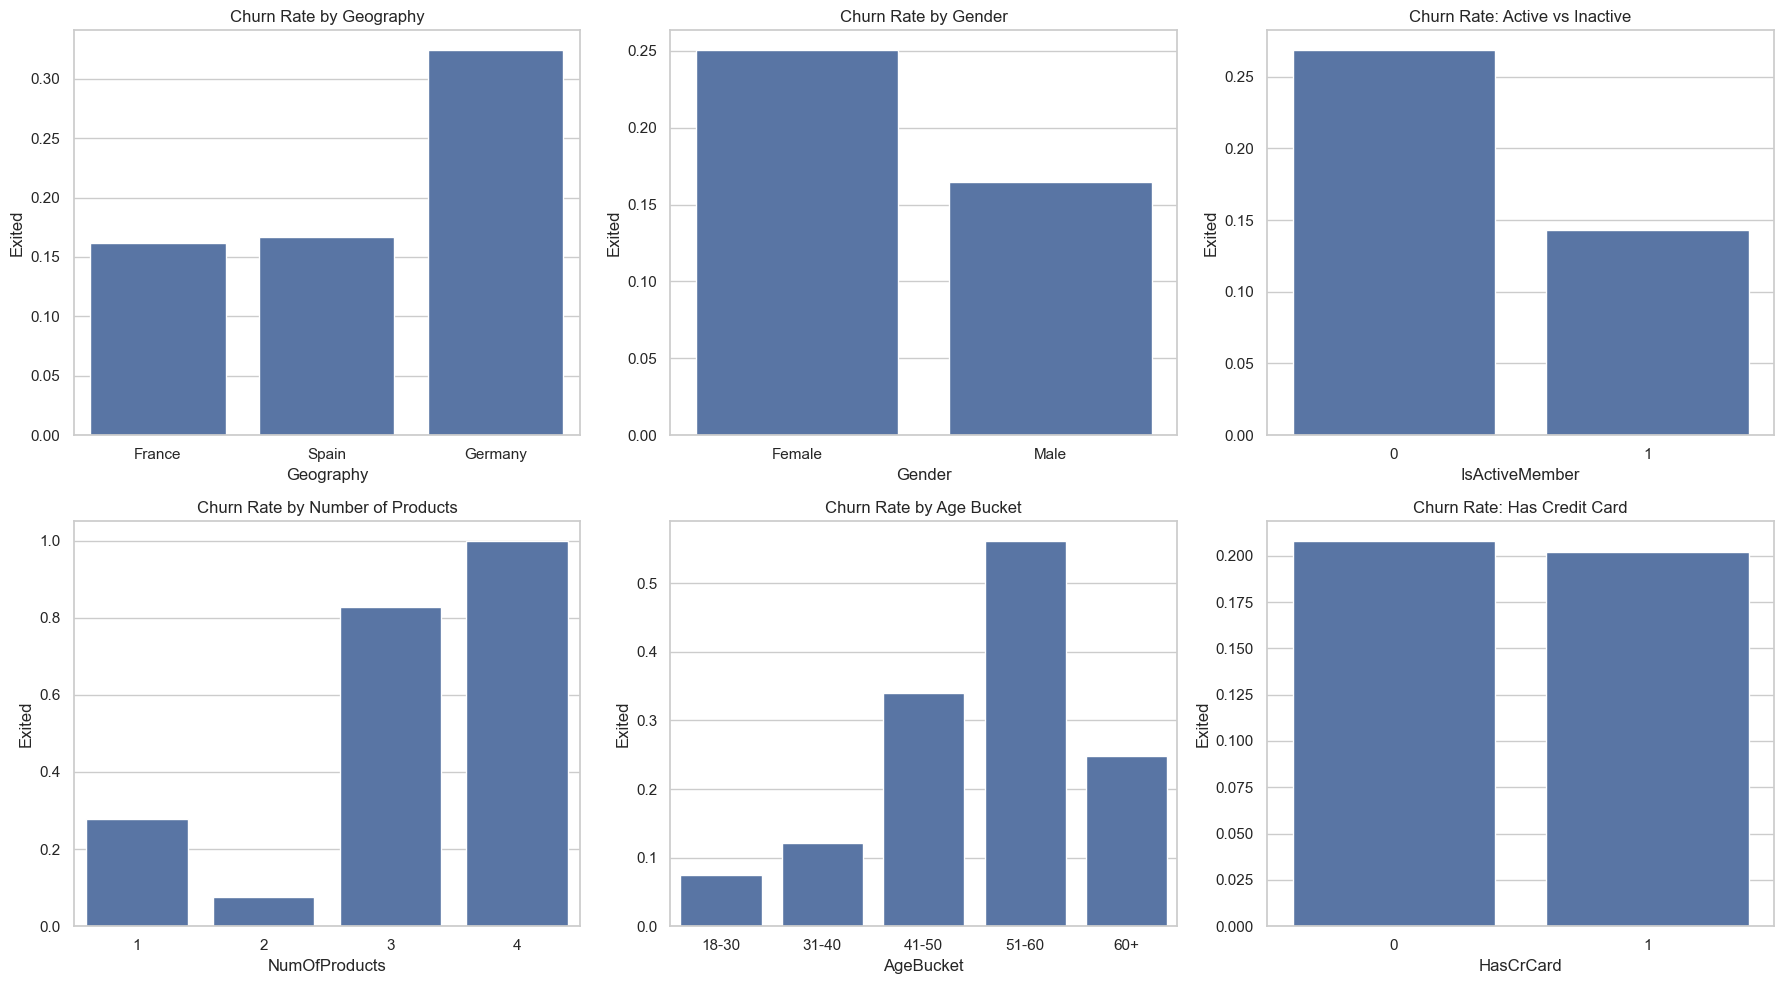

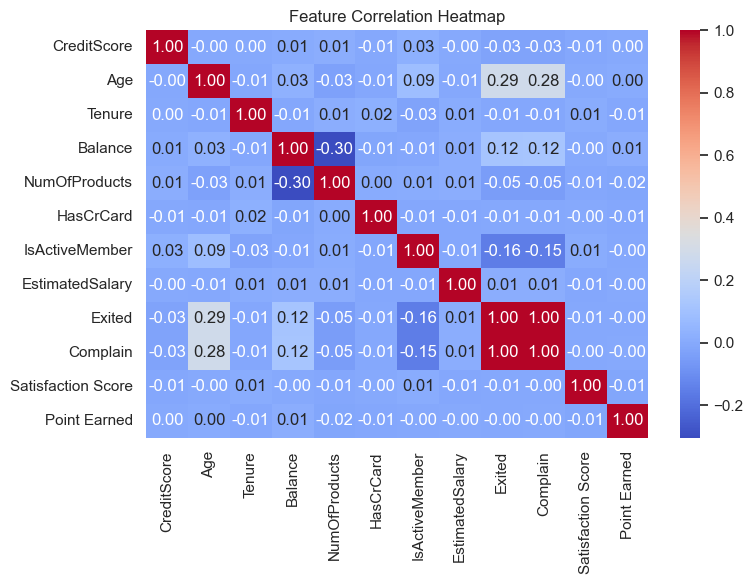

In [20]:
"""
STEP 2 — DATA CLEANING
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# ===========================================================
# 1. LOAD DATASET
# ===========================================================

df = pd.read_csv("Customer-Churn-Records.csv")

print("Original Shape:", df.shape)


# ===========================================================
# 2. CHECK DATA TYPES
# ===========================================================

print("\n========== DATA TYPES ==========")

print(df.dtypes)


# ===========================================================
# 3. CHECK MISSING VALUES
# ===========================================================

print("\n========== MISSING VALUES ==========")

print(df.isnull().sum())


# ===========================================================
# 4. CHECK DUPLICATE ROWS
# ===========================================================

before = len(df)

df = df.drop_duplicates()

after = len(df)

print("\nDuplicate rows removed:", before - after)

print(
    "Shape after removing duplicates:",
    df.shape
)


# ===========================================================
# 5. DROP UNNECESSARY IDENTIFIER COLUMNS
# ===========================================================

columns_to_drop = [
    "RowNumber",
    "CustomerId",
    "Surname"
]

df = df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print(
    "\nDropped identifier columns:",
    columns_to_drop
)


# ===========================================================
# 6. REMOVE TARGET-LEAKING COLUMN
# ===========================================================

# Complain is almost a duplicate of Exited in this dataset.
# Keeping it would cause severe data leakage.

if "Complain" in df.columns:

    print("\nWARNING: Target leakage detected!")

    print(
        "Complain column is highly correlated with Exited."
    )

    df = df.drop(
        columns=["Complain"]
    )

    print(
        "Complain column removed successfully."
    )

else:

    print(
        "\nComplain column not found."
    )


# Verify that Complain has been removed

print(
    "Complain present:",
    "Complain" in df.columns
)


# ===========================================================
# 7. SANITY CHECKS
# ===========================================================

print("\n========== SANITY CHECKS ==========")

for col in [
    "Age",
    "Balance",
    "CreditScore"
]:

    if col in df.columns:

        print(
            f"{col}:",
            df[col].min(),
            "-",
            df[col].max()
        )


# ===========================================================
# 8. CHECK CATEGORICAL COLUMNS
# ===========================================================

print(
    "\n========== CATEGORICAL COLUMNS =========="
)

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_columns:

    print(f"\n{col}:")

    print(
        df[col].value_counts()
    )


# ===========================================================
# 9. CHECK TARGET VARIABLE
# ===========================================================

print(
    "\n========== TARGET VARIABLE =========="
)

print(
    df["Exited"].value_counts()
)

print(
    "\nChurn Rate:",
    round(df["Exited"].mean(), 3)
)

print(
    "Churn Rate (%):",
    round(df["Exited"].mean() * 100, 2),
    "%"
)


# ===========================================================
# 10. FINAL DATASET INFORMATION
# ===========================================================

print(
    "\n========== FINAL CLEANED DATA =========="
)

print(
    "Final Shape:",
    df.shape
)

print(
    "\nMissing values:"
)

print(
    df.isnull().sum()
)

print(
    "\nFirst 5 rows:"
)

display(
    df.head()
)


# ===========================================================
# 11. FINAL LEAKAGE CHECK
# ===========================================================

print(
    "\n========== LEAKAGE CHECK =========="
)

assert "Complain" not in df.columns, \
    "ERROR: Complain is still present!"

print(
    "✓ Complain successfully removed."
)

print(
    "✓ Dataset is ready for Step 3 — EDA."
)

Original Shape: (10000, 18)

========== DATA TYPES ==========
RowNumber               int64
CustomerId              int64
Surname                object
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object

========== MISSING VALUES ==========
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain  

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425



========== LEAKAGE CHECK ==========
✓ Complain successfully removed.
✓ Dataset is ready for Step 3 — EDA.


In [6]:
"""
STEP 3 — EXPLORATORY DATA ANALYSIS
"""

# -----------------------------------------------------------
# 1. Churn by Geography
# -----------------------------------------------------------

churn_by_geography = (
    df.groupby("Geography")["Exited"]
    .agg(
        TotalCustomers="count",
        ChurnedCustomers="sum",
        ChurnRate="mean"
    )
    .reset_index()
)

churn_by_geography["ChurnRate"] *= 100

print("========== CHURN BY GEOGRAPHY ==========")
display(churn_by_geography)


# -----------------------------------------------------------
# 2. Churn by Gender
# -----------------------------------------------------------

churn_by_gender = (
    df.groupby("Gender")["Exited"]
    .agg(
        TotalCustomers="count",
        ChurnedCustomers="sum",
        ChurnRate="mean"
    )
    .reset_index()
)

churn_by_gender["ChurnRate"] *= 100

print("========== CHURN BY GENDER ==========")
display(churn_by_gender)


# -----------------------------------------------------------
# 3. Churn by Active Member
# -----------------------------------------------------------

churn_by_active_member = (
    df.groupby("IsActiveMember")["Exited"]
    .agg(
        TotalCustomers="count",
        ChurnedCustomers="sum",
        ChurnRate="mean"
    )
    .reset_index()
)

churn_by_active_member["IsActiveMember"] = (
    churn_by_active_member["IsActiveMember"]
    .map({0: "Inactive", 1: "Active"})
)

churn_by_active_member["ChurnRate"] *= 100

print("========== CHURN BY ACTIVE MEMBER ==========")
display(churn_by_active_member)


# -----------------------------------------------------------
# 4. Churn by Number of Products
# -----------------------------------------------------------

churn_by_products = (
    df.groupby("NumOfProducts")["Exited"]
    .agg(
        TotalCustomers="count",
        ChurnedCustomers="sum",
        ChurnRate="mean"
    )
    .reset_index()
)

churn_by_products["ChurnRate"] *= 100

print("========== CHURN BY PRODUCTS ==========")
display(churn_by_products)


# -----------------------------------------------------------
# 5. Create Age Buckets
# -----------------------------------------------------------

bins = [17, 25, 35, 45, 55, 65, np.inf]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df["AgeBucket"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)


# -----------------------------------------------------------
# 6. Churn by Age Bucket
# -----------------------------------------------------------

churn_by_age = (
    df.groupby("AgeBucket", observed=False)["Exited"]
    .agg(
        TotalCustomers="count",
        ChurnedCustomers="sum",
        ChurnRate="mean"
    )
    .reset_index()
)

churn_by_age["ChurnRate"] *= 100

print("========== CHURN BY AGE ==========")
display(churn_by_age)


# -----------------------------------------------------------
# 7. Overall Churn
# -----------------------------------------------------------

total_customers = len(df)

total_churned = df["Exited"].sum()

overall_churn_rate = (
    total_churned / total_customers
) * 100

total_retained = total_customers - total_churned

retention_rate = (
    total_retained / total_customers
) * 100

print("========== OVERALL CHURN ==========")
print("Total Customers:", total_customers)
print("Total Churned:", total_churned)
print("Total Retained:", total_retained)
print("Overall Churn Rate:", round(overall_churn_rate, 2), "%")
print("Retention Rate:", round(retention_rate, 2), "%")

========== CHURN BY GEOGRAPHY ==========


,Geography,TotalCustomers,ChurnedCustomers,ChurnRate
0,France,5014,811,16.174711
1,Germany,2509,814,32.443204
2,Spain,2477,413,16.673395


========== CHURN BY GENDER ==========


,Gender,TotalCustomers,ChurnedCustomers,ChurnRate
0,Female,4543,1139,25.071539
1,Male,5457,899,16.474253


========== CHURN BY ACTIVE MEMBER ==========


...

========== CHURN BY PRODUCTS ==========


,NumOfProducts,TotalCustomers,ChurnedCustomers,ChurnRate
0,1,5084,1409,27.714398
1,2,4590,349,7.603486
2,3,266,220,82.706767
3,4,60,60,100.000000


========== CHURN BY AGE ==========


,AgeBucket,TotalCustomers,ChurnedCustomers,ChurnRate
0,18-25,611,46,7.528642
1,26-35,3542,301,8.498024
2,36-45,3736,734,19.646681
3,46-55,1311,663,50.572082
4,56-65,536,259,48.320896
5,66+,264,35,13.257576


========== OVERALL CHURN ==========
Total Customers: 10000
Total Churned: 2038
Total Retained: 7962
Overall Churn Rate: 20.38 %
Retention Rate: 79.62 %


========== CORRELATION WITH EXITED ==========
Exited                1.000000
Age                   0.285296
Balance               0.118577
EstimatedSalary       0.012490
Point Earned         -0.004628
Satisfaction Score   -0.005849
HasCrCard            -0.006976
Tenure               -0.013656
CreditScore          -0.026771
NumOfProducts        -0.047611
IsActiveMember       -0.156356
Name: Exited, dtype: float64


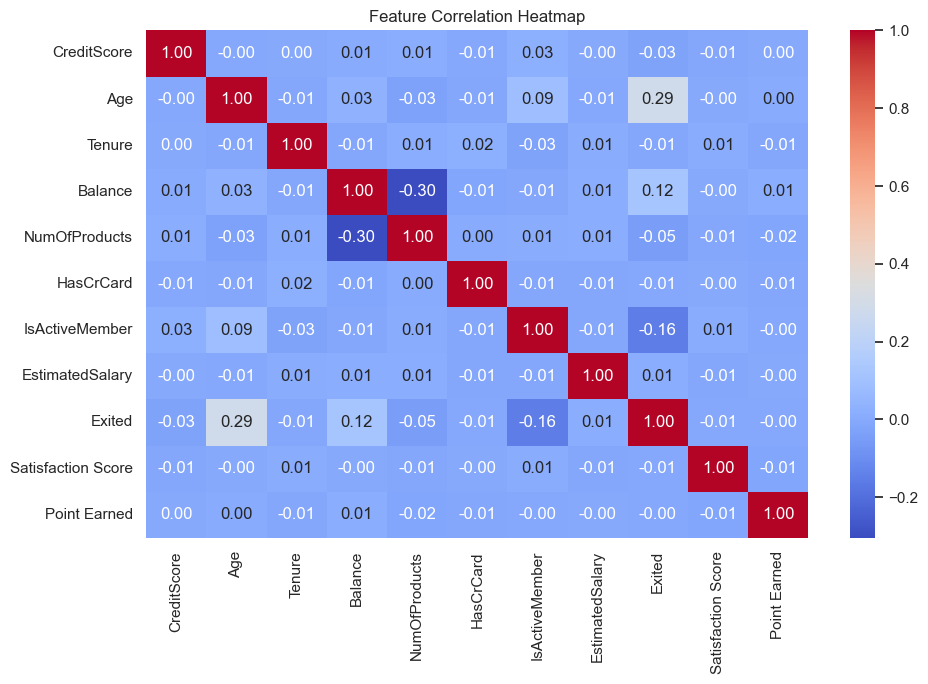


Categorical columns found:
['Geography', 'Gender', 'Card Type']

X shape: (10000, 16)
y shape: (10000,)

Non-numeric columns remaining:
['Geography_Germany', 'Geography_Spain', 'Gender_Male', 'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER']



========== RANDOM FOREST FEATURE IMPORTANCE ==========


,Importance
Age,0.212288
NumOfProducts,0.124315
Balance,0.109818
Point Earned,0.103790
CreditScore,0.103177
EstimatedSalary,0.102926
Tenure,0.060128
Satisfaction Score,0.040554
IsActiveMember,0.037777
Geography_Germany,0.025603


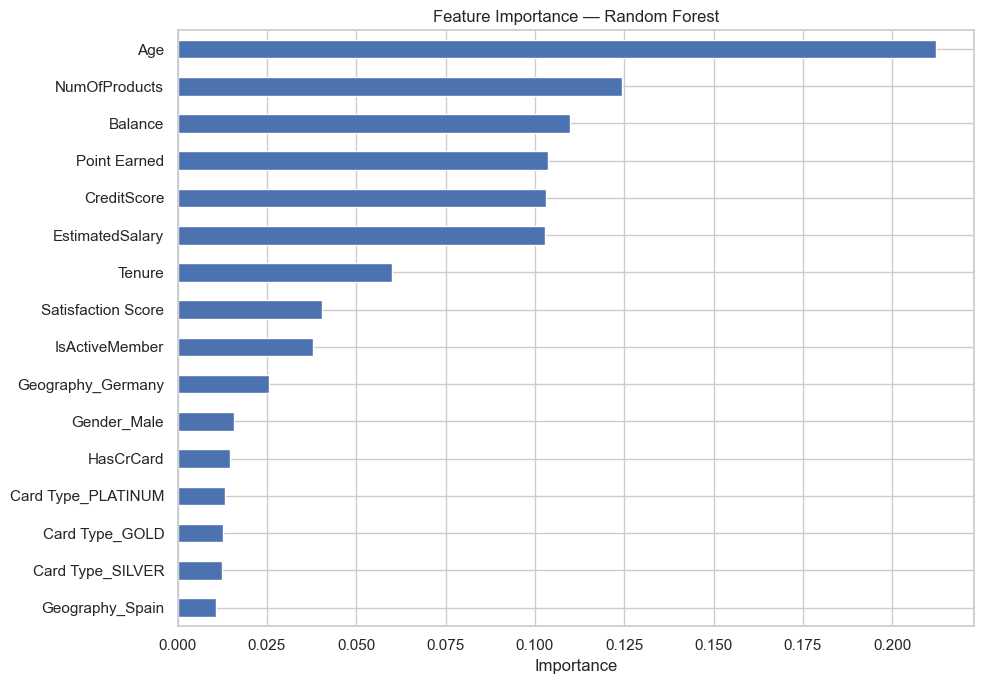

EDA tables saved successfully.


In [24]:
"""
STEP 4 — FEATURE SELECTION
"""

from sklearn.ensemble import RandomForestClassifier

# -----------------------------------------------------------
# 1. Correlation analysis
# -----------------------------------------------------------

numeric_df = df.select_dtypes(include=[np.number])

corr = (
    numeric_df
    .corr()["Exited"]
    .sort_values(ascending=False)
)

print("========== CORRELATION WITH EXITED ==========")
print(corr)


# -----------------------------------------------------------
# 2. Correlation Heatmap
# -----------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    "correlation_heatmap.png",
    dpi=150
)

plt.show()


# -----------------------------------------------------------
# 3. Prepare data for Random Forest
# -----------------------------------------------------------

# Remove AgeBucket because it was created only for EDA
df_model = df.drop(
    columns=["AgeBucket"],
    errors="ignore"
).copy()


# Find ALL categorical columns automatically
categorical_columns = df_model.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nCategorical columns found:")
print(categorical_columns)


# -----------------------------------------------------------
# 4. One-hot encode ALL categorical columns
# -----------------------------------------------------------

temp_encoded = pd.get_dummies(
    df_model,
    columns=categorical_columns,
    drop_first=True
)


# Make sure all values are numeric
X_temp = temp_encoded.drop(columns=["Exited"])
y_temp = temp_encoded["Exited"]

print("\nX shape:", X_temp.shape)
print("y shape:", y_temp.shape)

print("\nNon-numeric columns remaining:")
print(X_temp.select_dtypes(exclude=[np.number]).columns.tolist())


# -----------------------------------------------------------
# 5. Random Forest Feature Importance
# -----------------------------------------------------------

rf_selector = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_temp, y_temp)


# -----------------------------------------------------------
# 6. Display Feature Importance
# -----------------------------------------------------------

importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_temp.columns
)

importance = importance.sort_values(
    ascending=False
)

print("\n========== RANDOM FOREST FEATURE IMPORTANCE ==========")
display(importance.to_frame("Importance"))


# -----------------------------------------------------------
# 7. Feature Importance Plot
# -----------------------------------------------------------

plt.figure(figsize=(10, 7))

importance.plot(kind="barh")

plt.title("Feature Importance — Random Forest")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=150
)

plt.show()


churn_by_geography.to_csv("churn_by_geography.csv", index=False)
churn_by_gender.to_csv("churn_by_gender.csv", index=False)
churn_by_active_member.to_csv("churn_by_active_member.csv", index=False)
churn_by_products.to_csv("churn_by_products.csv", index=False)
churn_by_age.to_csv("churn_by_age.csv", index=False)

print("EDA tables saved successfully.")

In [25]:
"""
STEP 5 — FINAL ENCODING
"""

# Start from cleaned dataset
df_encoded = df.drop(
    columns=["AgeBucket"],
    errors="ignore"
).copy()


# -----------------------------------------------------------
# Find all categorical columns
# -----------------------------------------------------------

categorical_columns = df_encoded.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns to encode:")
print(categorical_columns)


# -----------------------------------------------------------
# One-hot encoding
# -----------------------------------------------------------

df_encoded = pd.get_dummies(
    df_encoded,
    columns=categorical_columns,
    drop_first=True
)


# -----------------------------------------------------------
# Verify everything is numeric
# -----------------------------------------------------------

print("\n========== ENCODED DATA ==========")

print("Shape:", df_encoded.shape)

print("\nEncoded columns:")
print(df_encoded.columns.tolist())

print("\nNon-numeric columns:")
print(
    df_encoded
    .select_dtypes(exclude=[np.number])
    .columns
    .tolist()
)


# -----------------------------------------------------------
# Save
# -----------------------------------------------------------

df_encoded.to_csv(
    "churn_cleaned_encoded.csv",
    index=False
)

print("\nSaved:")
print("churn_cleaned_encoded.csv")

print("\nReady for Step 6: Train-Test Split → Model Training")

Categorical columns to encode:
['Geography', 'Gender', 'Card Type']

========== ENCODED DATA ==========
Shape: (10000, 17)

Encoded columns:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Satisfaction Score', 'Point Earned', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER']

Non-numeric columns:
['Geography_Germany', 'Geography_Spain', 'Gender_Male', 'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER']

Saved:
churn_cleaned_encoded.csv

Ready for Step 6: Train-Test Split → Model Training


In [26]:
df.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,5,DIAMOND,484
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0,2,SILVER,206
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,2,DIAMOND,282
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,3,GOLD,251
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,3,GOLD,342


In [27]:
"""
STEP 6 — TRAIN-TEST SPLIT
"""

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# -----------------------------------------------------------
# 1. Load encoded dataset
# -----------------------------------------------------------

df = pd.read_csv("churn_cleaned_encoded.csv")

print("Dataset shape:", df.shape)


# -----------------------------------------------------------
# 2. Separate features and target
# -----------------------------------------------------------

X = df.drop(columns=["Exited"])
y = df["Exited"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


# -----------------------------------------------------------
# 3. Train-Test Split
# -----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# -----------------------------------------------------------
# 4. Check split
# -----------------------------------------------------------

print("\n========== TRAIN-TEST SPLIT ==========")

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

print("\nTraining churn rate:", round(y_train.mean(), 3))
print("Testing churn rate :", round(y_test.mean(), 3))


# -----------------------------------------------------------
# 5. Feature Scaling
# -----------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling completed.")

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Dataset shape: (10000, 17)

Features shape: (10000, 16)
Target shape: (10000,)

========== TRAIN-TEST SPLIT ==========
Training data: (8000, 16)
Testing data : (2000, 16)

Training churn rate: 0.204
Testing churn rate : 0.204

Scaling completed.
Scaled training shape: (8000, 16)
Scaled testing shape : (2000, 16)


In [28]:
"""
STEP 7 — MODEL TRAINING
"""

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# -----------------------------------------------------------
# 1. Define models
# -----------------------------------------------------------

models = {

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}


# -----------------------------------------------------------
# 2. Train models
# -----------------------------------------------------------

trained_models = {}

predictions = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    # Logistic Regression needs scaled data
    if name == "Logistic Regression":

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

        y_prob = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        # Tree-based models use original data
        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

        y_prob = model.predict_proba(
            X_test
        )[:, 1]

    trained_models[name] = model

    predictions[name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    print(f"{name} training completed.")


print("\n========== ALL MODELS TRAINED ==========")
print(list(trained_models.keys()))


Training Logistic Regression...
Logistic Regression training completed.

Training Random Forest...


Random Forest training completed.

Training XGBoost...


XGBoost training completed.

========== ALL MODELS TRAINED ==========
['Logistic Regression', 'Random Forest', 'XGBoost']


In [29]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [30]:
from xgboost import XGBClassifier

print("XGBoost installed successfully!")

XGBoost installed successfully!



Logistic Regression
              precision    recall  f1-score   support

    Retained       0.91      0.71      0.80      1592
     Churned       0.39      0.72      0.51       408

    accuracy                           0.71      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.80      0.71      0.74      2000



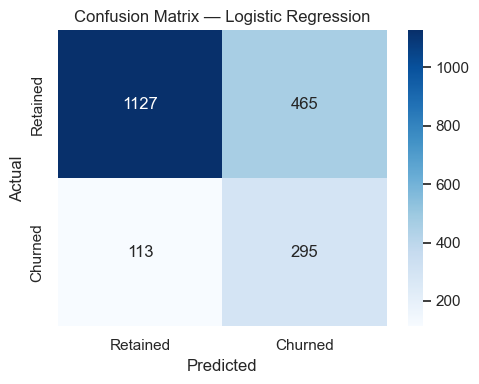

Saved: confusion_matrix_Logistic_Regression.png

Random Forest
              precision    recall  f1-score   support

    Retained       0.87      0.97      0.92      1592
     Churned       0.81      0.44      0.57       408

    accuracy                           0.86      2000
   macro avg       0.84      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000



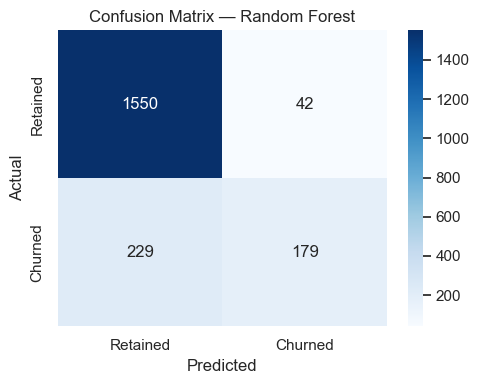

Saved: confusion_matrix_Random_Forest.png

XGBoost
              precision    recall  f1-score   support

    Retained       0.93      0.83      0.88      1592
     Churned       0.53      0.74      0.62       408

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.81      0.82      2000



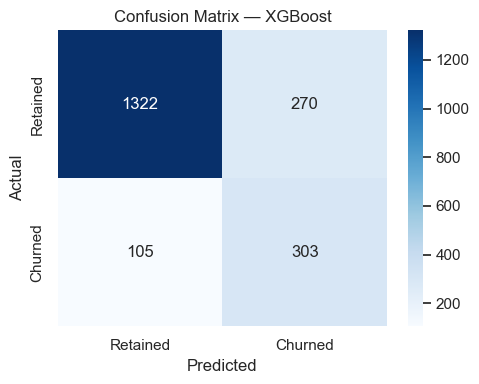

Saved: confusion_matrix_XGBoost.png


========== MODEL COMPARISON ==========


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,XGBoost,0.8125,0.528796,0.742647,0.617737,0.867855
1,Random Forest,0.8645,0.809955,0.438725,0.569157,0.871033
0,Logistic Regression,0.7110,0.388158,0.723039,0.505137,0.779718



Saved: model_comparison_results.csv


In [31]:
"""
STEP 8 — MODEL EVALUATION
"""

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


results = []


# -----------------------------------------------------------
# Evaluate every model
# -----------------------------------------------------------

for name in trained_models.keys():

    y_pred = predictions[name]["y_pred"]
    y_prob = predictions[name]["y_prob"]


    # -------------------------------------------------------
    # Calculate metrics
    # -------------------------------------------------------

    metrics = {

        "Model": name,

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred
        ),

        "Recall": recall_score(
            y_test,
            y_pred
        ),

        "F1-score": f1_score(
            y_test,
            y_pred
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        )
    }

    results.append(metrics)


    # -------------------------------------------------------
    # Classification Report
    # -------------------------------------------------------

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Retained",
                "Churned"
            ]
        )
    )


    # -------------------------------------------------------
    # Confusion Matrix
    # -------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Retained",
            "Churned"
        ],
        yticklabels=[
            "Retained",
            "Churned"
        ]
    )

    plt.title(
        f"Confusion Matrix — {name}"
    )

    plt.ylabel("Actual")
    plt.xlabel("Predicted")

    plt.tight_layout()

    filename = (
        f"confusion_matrix_"
        f"{name.replace(' ', '_')}.png"
    )

    plt.savefig(
        filename,
        dpi=150
    )

    plt.show()

    print("Saved:", filename)


# -----------------------------------------------------------
# Model comparison
# -----------------------------------------------------------

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "F1-score",
    ascending=False
)

print("\n\n========== MODEL COMPARISON ==========")

display(results_df)


# Save results

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print(
    "\nSaved: model_comparison_results.csv"
)

In [34]:
"""
STEP 9.5 — XGBOOST THRESHOLD TUNING
"""
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Get XGBoost model
xgb_model = trained_models["XGBoost"]

# Get churn probabilities
xgb_prob = predictions["XGBoost"]["y_prob"]


# -----------------------------------------------------------
# Test different probability thresholds
# -----------------------------------------------------------

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

threshold_results = []


for threshold in thresholds:

    # Convert probability into prediction
    y_pred_threshold = (
        xgb_prob >= threshold
    ).astype(int)


    threshold_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),

        "Precision": precision_score(
            y_test,
            y_pred_threshold
        ),

        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),

        "F1-score": f1_score(
            y_test,
            y_pred_threshold
        )
    })


threshold_df = pd.DataFrame(
    threshold_results
)
print("========== XGBOOST THRESHOLD COMPARISON ==========")
display(threshold_df)

========== XGBOOST THRESHOLD COMPARISON ==========


,Threshold,Accuracy,Precision,Recall,F1-score
0,0.30,0.7025,0.395062,0.862745,0.541955
1,0.35,0.7440,0.433673,0.833333,0.570470
2,0.40,0.7680,0.460563,0.801471,0.584973
3,0.45,0.7960,0.500000,0.774510,0.607692
4,0.50,0.8125,0.528796,0.742647,0.617737
5,0.55,0.8315,0.571429,0.696078,0.627624
6,0.60,0.8470,0.614865,0.669118,0.640845


In [35]:
"""
XGBOOST — ACTUAL PREDICTION OUTPUT
"""

# Get trained XGBoost model
xgb_model = trained_models["XGBoost"]

# Get probabilities
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

# Use 0.50 threshold for retention-focused prediction
threshold = 0.50

xgb_predictions = (
    xgb_probabilities >= threshold
).astype(int)


# -----------------------------------------------------------
# Create prediction output
# -----------------------------------------------------------

prediction_output = X_test.copy()

prediction_output["Actual_Exited"] = y_test.values

prediction_output["Churn_Probability"] = xgb_probabilities

prediction_output["Predicted_Exited"] = xgb_predictions

prediction_output["Prediction"] = prediction_output[
    "Predicted_Exited"
].map({
    0: "Retained",
    1: "Churned"
})


# -----------------------------------------------------------
# Display first 20 predictions
# -----------------------------------------------------------

print("========== XGBOOST PREDICTIONS ==========")

display(
    prediction_output[
        [
            "Actual_Exited",
            "Churn_Probability",
            "Predicted_Exited",
            "Prediction"
        ]
    ].head(20)
)

========== XGBOOST PREDICTIONS ==========


,Actual_Exited,Churn_Probability,Predicted_Exited,Prediction
6176,0,0.366207,0,Retained
7072,0,0.270922,0,Retained
877,0,0.108475,0,Retained
6539,1,0.271947,0,Retained
5190,0,0.078816,0,Retained
9727,1,0.876706,1,Churned
6561,1,0.633129,1,Churned
4711,0,0.403889,0,Retained
9099,0,0.011262,0,Retained
5975,0,0.097925,0,Retained


In [36]:
df.head(10)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Gender_Male,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,42,2,0.00,1,1,1,101348.88,1,2,464,False,False,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,3,456,False,True,False,False,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,3,377,False,False,False,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,5,350,False,False,False,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,5,425,False,True,False,True,False,False
5,645,44,8,113755.78,2,1,0,149756.71,1,5,484,False,True,True,False,False,False
6,822,50,7,0.00,2,1,1,10062.80,0,2,206,False,False,True,False,False,True
7,376,29,4,115046.74,4,1,0,119346.88,1,2,282,True,False,False,False,False,False
8,501,44,4,142051.07,2,0,1,74940.50,0,3,251,False,False,True,True,False,False
9,684,27,2,134603.88,1,1,1,71725.73,0,3,342,False,False,True,True,False,False


In [40]:
import joblib
import pandas as pd

# 1. Load the model file
model = joblib.load('churn_model.pkl')

# 2. Create sample customer data (match your model's exact columns)
# Replace these column names and values with your actual data structure
sample_data = pd.DataFrame([{
    'tenure': 12,
    'monthly_charges': 70.5,
    'total_charges': 846.0,
    'tech_support': 1  # 1 for Yes, 0 for No
}])

# 3. Check the prediction (0 = Stays, 1 = Churns)
prediction = model.predict(sample_data)
print(f"Prediction: {prediction}")

# 4. Check the probability score (e.g., 85% chance of churning)
probability = model.predict_proba(sample_data)
print(f"Probability (Stay vs Churn): {probability}")


FileNotFoundError: [Errno 2] No such file or directory: 'churn_model.pkl'

In [38]:
"""
Bank Customer Churn — Final Deployment Script
================================================
Trains the final, leakage-free XGBoost model, evaluates it,
and saves all artifacts needed for Streamlit/Flask deployment.
"""

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# ===========================================================
# 1. LOAD CORRECTED DATASET + LEAKAGE CHECK
# ===========================================================
df = pd.read_csv("churn_cleaned_encoded.csv")

# Hard stop if the leaking column is somehow still present
if "Complain" in df.columns:
    raise ValueError(
        "Leakage detected: 'Complain' column is present in the dataset. "
        "This column is almost perfectly correlated with 'Exited' and must "
        "be removed before training. Aborting."
    )

print("Leakage check passed: 'Complain' is not present in the dataset.")
print("Dataset shape:", df.shape)

# ===========================================================
# 2. SEPARATE FEATURES AND TARGET
# ===========================================================
X = df.drop(columns=["Exited"])
y = df["Exited"]

# ===========================================================
# 3. REPRODUCIBLE TRAIN-TEST SPLIT
# ===========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

# ===========================================================
# 4. TRAIN FINAL XGBOOST MODEL
# ===========================================================
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handles class imbalance
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model training complete.")

# ===========================================================
# 5. EVALUATE FINAL MODEL
# ===========================================================
# --- Default threshold (0.5, via .predict()) ---
y_pred_default = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n" + "=" * 55)
print("EVALUATION AT DEFAULT THRESHOLD (0.50 via .predict())")
print("=" * 55)
print("Accuracy :", accuracy_score(y_test, y_pred_default))
print("Precision:", precision_score(y_test, y_pred_default))
print("Recall   :", recall_score(y_test, y_pred_default))
print("F1-score :", f1_score(y_test, y_pred_default))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_default))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_default, target_names=["Retained", "Churned"]))

# --- Deployment threshold (explicit, configurable) ---
THRESHOLD = 0.50  # configurable deployment threshold

y_pred_threshold = (y_prob >= THRESHOLD).astype(int)

print("=" * 55)
print(f"EVALUATION AT DEPLOYMENT THRESHOLD ({THRESHOLD})")
print("=" * 55)
print("Accuracy :", accuracy_score(y_test, y_pred_threshold))
print("Precision:", precision_score(y_test, y_pred_threshold))
print("Recall   :", recall_score(y_test, y_pred_threshold))
print("F1-score :", f1_score(y_test, y_pred_threshold))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_threshold))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_threshold, target_names=["Retained", "Churned"]))

# ===========================================================
# 6. SAVE FINAL MODEL
# ===========================================================
joblib.dump(model, "best_churn_model.pkl")
print("\nSaved: best_churn_model.pkl")

# ===========================================================
# 7. SAVE EXACT FEATURE-COLUMN ORDER
# ===========================================================
feature_columns = list(X.columns)
joblib.dump(feature_columns, "feature_columns.pkl")
print("Saved: feature_columns.pkl")

# ===========================================================
# 8. SAVE DEPLOYMENT CONFIG
# ===========================================================
churn_config = {
    "threshold": THRESHOLD,
    "model_name": "XGBoost",
    "target": "Exited"
}
joblib.dump(churn_config, "churn_config.pkl")
print("Saved: churn_config.pkl")

# ===========================================================
# 9. NOTE: NO SCALER SAVED
# ===========================================================
# XGBoost is tree-based and does not require feature scaling.
# No StandardScaler is fit or saved for this deployment pipeline.

# ===========================================================
# 10. VERIFY SAVED FILES WORK
# ===========================================================
loaded_model = joblib.load("best_churn_model.pkl")
loaded_features = joblib.load("feature_columns.pkl")
loaded_config = joblib.load("churn_config.pkl")

# Predict on one test customer using the loaded model
sample = X_test.iloc[[0]][loaded_features]  # enforce correct column order
original_prob = model.predict_proba(sample)[:, 1][0]
loaded_prob = loaded_model.predict_proba(sample)[:, 1][0]

original_pred = int(original_prob >= loaded_config["threshold"])
loaded_pred = int(loaded_prob >= loaded_config["threshold"])

prediction_matches = (original_pred == loaded_pred) and np.isclose(original_prob, loaded_prob)

# ===========================================================
# 11. FINAL DEPLOYMENT SUMMARY
# ===========================================================
print("\n" + "=" * 55)
print("FINAL DEPLOYMENT SUMMARY")
print("=" * 55)
print(f"Model: {loaded_config['model_name']}")
print(f"Threshold: {loaded_config['threshold']}")
print(f"Number of features: {len(loaded_features)}")

print("\nSaved files:")
print("\u2713 best_churn_model.pkl")
print("\u2713 feature_columns.pkl")
print("\u2713 churn_config.pkl")

print("\nLeakage check:")
print("\u2713 Complain is not present")

print("\nModel verification:")
print("\u2713 Saved model successfully loaded" if loaded_model is not None else "\u2717 Load failed")
print("\u2713 Prediction successfully reproduced" if prediction_matches else "\u2717 Prediction mismatch")

print("\nReady for Streamlit/Flask deployment.")

Leakage check passed: 'Complain' is not present in the dataset.
Dataset shape: (10000, 17)
Train shape: (8000, 16) | Test shape: (2000, 16)


Model training complete.

EVALUATION AT DEFAULT THRESHOLD (0.50 via .predict())
Accuracy : 0.8125
Precision: 0.5287958115183246
Recall   : 0.7426470588235294
F1-score : 0.617737003058104
ROC-AUC  : 0.8678548994974875

Confusion Matrix:
 [[1322  270]
 [ 105  303]]

Classification Report:
               precision    recall  f1-score   support

    Retained       0.93      0.83      0.88      1592
     Churned       0.53      0.74      0.62       408

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.81      0.82      2000

EVALUATION AT DEPLOYMENT THRESHOLD (0.5)
Accuracy : 0.8125
Precision: 0.5287958115183246
Recall   : 0.7426470588235294
F1-score : 0.617737003058104
ROC-AUC  : 0.8678548994974875

Confusion Matrix:
 [[1322  270]
 [ 105  303]]

Classification Report:
               precision    recall  f1-score   support

    Retained       0.93      0.83      0.88      1592
     Churned       0.53  


FINAL DEPLOYMENT SUMMARY
Model: XGBoost
Threshold: 0.5
Number of features: 16

Saved files:
✓ best_churn_model.pkl
✓ feature_columns.pkl
✓ churn_config.pkl

Leakage check:
✓ Complain is not present

Model verification:
✓ Saved model successfully loaded
✓ Prediction successfully reproduced

Ready for Streamlit/Flask deployment.


In [39]:
import joblib
import pandas as pd

# Load saved files
model = joblib.load("best_churn_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")
config = joblib.load("churn_config.pkl")

print("========== DEPLOYMENT FILE CHECK ==========")

print("Model loaded:", type(model).__name__)
print("Number of features:", len(feature_columns))
print("Threshold:", config["threshold"])
print("Model name:", config["model_name"])
print("Target:", config["target"])

print("\nFeature columns:")
print(feature_columns)

print("\n✓ All deployment files loaded successfully.")

========== DEPLOYMENT FILE CHECK ==========
Model loaded: XGBClassifier
Number of features: 16
Threshold: 0.5
Model name: XGBoost
Target: Exited

Feature columns:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER']

✓ All deployment files loaded successfully.
